In [23]:
import pygame
import heapq
import random
import time

# Define colors
BLACK = (0, 0, 0)
WHITE = (255, 255, 255)
GREEN = (0, 255, 0)
RED = (255, 0, 0)
BLUE = (0, 0, 255)
BROWN = (165, 42, 42)
GRAY = (128, 128, 128)
YELLOW = (255, 255, 0)

# Define grid size
GRID_SIZE = 15

# Define window size
WINDOW_SIZE = [600, 600]

# Define cell size
CELL_SIZE = WINDOW_SIZE[0] // GRID_SIZE

# Define obstacle probability
OBSTACLE_PROBABILITY = 0.3  # Increased probability

# Define delivery locations
DELIVERY_LOCATIONS = []
for _ in range(5):
    x = random.randint(0, GRID_SIZE - 1)
    y = random.randint(0, GRID_SIZE - 1)
    DELIVERY_LOCATIONS.append((x, y))

# Initialize pygame
pygame.init()

# Set up the window
window = pygame.display.set_mode(WINDOW_SIZE)
pygame.display.set_caption("Autonomous Delivery Robot")

# Define the grid
grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

# Generate obstacles and cars
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if random.random() < OBSTACLE_PROBABILITY:
            grid[i][j] = random.choice([2, 3, 4])  # Representing different types of obstacles
        elif random.random() < 0.05:  # Adjust this probability as needed
            grid[i][j] = 5  # Representing cars

# Ensure robot and delivery locations are not blocked
grid[0][0] = 0  # Robot initial location
for loc in DELIVERY_LOCATIONS:
    grid[loc[0]][loc[1]] = 0

# Define the heuristic function
def heuristic(a, b):
    (x1, y1) = a
    (x2, y2) = b
    return abs(x1 - x2) + abs(y1 - y2)

# Define the A* algorithm
def astar(start, goal):
    frontier = []
    heapq.heappush(frontier, (0, start))
    came_from = {}
    cost_so_far = {}
    came_from[start] = None
    cost_so_far[start] = 0

    while frontier:
        current = heapq.heappop(frontier)[1]

        if current == goal:
            path = []
            while current != start:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path

        for next in [(current[0] + 1, current[1]), (current[0] - 1, current[1]),
                     (current[0], current[1] + 1), (current[0], current[1] - 1)]:
            if 0 <= next[0] < GRID_SIZE and 0 <= next[1] < GRID_SIZE and grid[next[0]][next[1]] == 0:
                new_cost = cost_so_far[current] + 1
                if next not in cost_so_far or new_cost < cost_so_far[next]:
                    cost_so_far[next] = new_cost
                    priority = new_cost + heuristic(next, goal)
                    heapq.heappush(frontier, (priority, next))
                    came_from[next] = current

    return []

def main():
    global DELIVERY_LOCATIONS
    running = True
    path = []
    start = (0, 0)

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        # Clear the window
        window.fill(WHITE)

        # Draw the grid
        for i in range(GRID_SIZE):
            for j in range(GRID_SIZE):
                rect = pygame.Rect(j * CELL_SIZE, i * CELL_SIZE, CELL_SIZE, CELL_SIZE)
                if grid[i][j] == 1:  # Normal grid
                    pygame.draw.rect(window, WHITE, rect, 1)
                elif grid[i][j] == 2:  # Trees
                    pygame.draw.rect(window, GREEN, rect)
                elif grid[i][j] == 3:  # Buildings
                    pygame.draw.rect(window, GRAY, rect)
                elif grid[i][j] == 4:  # Houses
                    pygame.draw.rect(window, BROWN, rect)
                elif grid[i][j] == 5:  # Cars
                    pygame.draw.rect(window, YELLOW, rect)

        # Draw the delivery locations
        for loc in DELIVERY_LOCATIONS:
            pygame.draw.circle(window, BLUE, (loc[1] * CELL_SIZE + CELL_SIZE // 2, loc[0] * CELL_SIZE + CELL_SIZE // 2), CELL_SIZE // 4)

        # Draw the robot
        pygame.draw.circle(window, RED, (start[1] * CELL_SIZE + CELL_SIZE // 2, start[0] * CELL_SIZE + CELL_SIZE // 2), CELL_SIZE // 3)

        # Draw the path
        if path:
            for i in range(len(path) - 1):
                pygame.draw.line(window, BLUE, (path[i][1] * CELL_SIZE + CELL_SIZE // 2, path[i][0] * CELL_SIZE + CELL_SIZE // 2),
                                 (path[i + 1][1] * CELL_SIZE + CELL_SIZE // 2, path[i + 1][0] * CELL_SIZE + CELL_SIZE // 2), 3)

        # Update the display
        pygame.display.flip()

        # Deliver items
        if DELIVERY_LOCATIONS:
            current_goal = min(DELIVERY_LOCATIONS, key=lambda loc: heuristic(start, loc))
            path = astar(start, current_goal)
            if path:
                while path:
                    next_step = path.pop(0)
                    pygame.draw.line(window, BLUE, (start[1] * CELL_SIZE + CELL_SIZE // 2, start[0] * CELL_SIZE + CELL_SIZE // 2),
                                     (next_step[1] * CELL_SIZE + CELL_SIZE // 2, next_step[0] * CELL_SIZE + CELL_SIZE // 2), 3)
                    start = next_step
                    pygame.draw.circle(window, RED, (start[1] * CELL_SIZE + CELL_SIZE // 2, start[0] * CELL_SIZE + CELL_SIZE // 2), CELL_SIZE // 3)
                    pygame.display.flip()
                    time.sleep(0.3)
                DELIVERY_LOCATIONS.remove(current_goal)
        else:
            # Return to initial location
            path_back = astar(start, (0, 0))
            if path_back:
                while path_back:
                    next_step = path_back.pop(0)
                    pygame.draw.line(window, BLUE, (start[1] * CELL_SIZE + CELL_SIZE // 2, start[0] * CELL_SIZE + CELL_SIZE // 2),
                                     (next_step[1] * CELL_SIZE + CELL_SIZE // 2, next_step[0] * CELL_SIZE + CELL_SIZE // 2), 3)
                    start = next_step
                    pygame.draw.circle(window, RED, (start[1] * CELL_SIZE + CELL_SIZE // 2, start[0] * CELL_SIZE + CELL_SIZE // 2), CELL_SIZE // 3)
                    pygame.display.flip()
                    time.sleep(0.3)
                    if not path_back:
                        DELIVERY_LOCATIONS.clear()  # All deliveries completed, clear the delivery locations list
            running = False  # Stop the loop once all deliveries are completed

    pygame.quit()

if __name__ == "__main__":
    main()

KeyboardInterrupt: 

Data Preprocessing:
   Batch                   Domain  Student_Count  Domain_Code
0     19         Computer Science            300            2
1     19  Artificial Intelligence            250            0
2     20       Business Analytics            280            1
3     20     Software Engineering            320            3
4     21         Computer Science            310            2
5     21  Artificial Intelligence            290            0
6     22       Business Analytics            330            1
7     22     Software Engineering            340            3


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



K-Means Clustering Results:
   Batch                   Domain  Student_Count  Domain_Code  Cluster
0     19         Computer Science            300            2        1
1     19  Artificial Intelligence            250            0        3
2     20       Business Analytics            280            1        2
3     20     Software Engineering            320            3        1
4     21         Computer Science            310            2        1
5     21  Artificial Intelligence            290            0        2
6     22       Business Analytics            330            1        0
7     22     Software Engineering            340            3        0

Seating Plan:
Room1:
   Batch                Domain  Student_Count  Domain_Code  Cluster
6     22    Business Analytics            330            1        0
7     22  Software Engineering            340            3        0

Room2:
   Batch                Domain  Student_Count  Domain_Code  Cluster
0     19      Computer Science

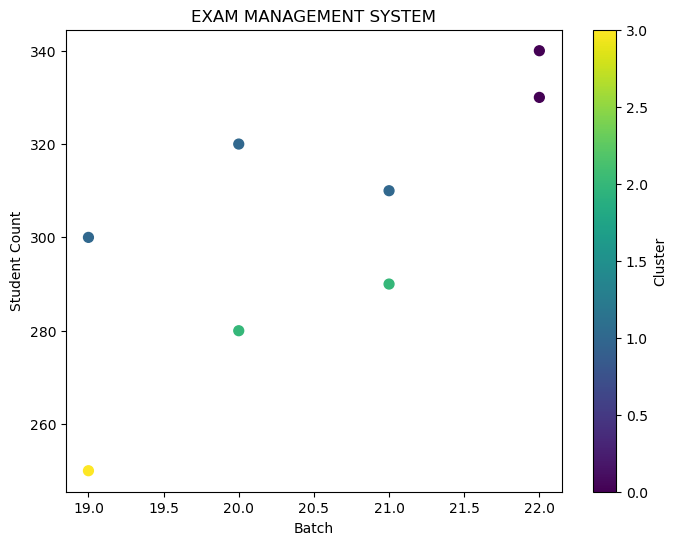

In [17]:
# Importing Libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Data Collection
# Sample data for demonstration
student_data = {
    'Batch': [19, 19, 20, 20, 21, 21, 22, 22],
    'Domain': ['Computer Science', 'Artificial Intelligence', 'Business Analytics', 'Software Engineering',
               'Computer Science', 'Artificial Intelligence', 'Business Analytics', 'Software Engineering'],
    'Student_Count': [300, 250, 280, 320, 310, 290, 330, 340]
}

room_data = {
    'Room_ID': ['Room1', 'Room2', 'Room3', 'Room4'],
    'Capacity': [30, 35, 25, 30]  # Room capacities
}

# Convert data to DataFrame
student_df = pd.DataFrame(student_data)
room_df = pd.DataFrame(room_data)

# Data Preprocessing
student_df['Domain_Code'] = pd.Categorical(student_df['Domain']).codes
print("Data Preprocessing:")
print(student_df)

# K-Means Clustering
X = student_df[['Batch', 'Domain_Code', 'Student_Count']]

# Fixed number of clusters for demonstration
k_means = KMeans(n_clusters=4)
k_means.fit(X)
student_df['Cluster'] = k_means.labels_
print("\nK-Means Clustering Results:")
print(student_df)

# Seating Plan
def generate_seating_plan(room_df, student_df):
    seating_plan = {}
    for index, room in room_df.iterrows():
        room_capacity = room['Capacity']
        available_students = student_df[student_df['Cluster'] == index]
        seating_plan[room['Room_ID']] = available_students
    return seating_plan

seating_plan = generate_seating_plan(room_df, student_df)
print("\nSeating Plan:")
for room, students in seating_plan.items():
    print(f"{room}:")
    print(students)
    print()

# Faculty Allocation
faculty_data = {
    'Faculty_ID': [1, 2, 3, 4],
    'Domain_Expertise': ['Computer Science', 'Artificial Intelligence', 'Business Analytics', 'Software Engineering']
}

faculty_df = pd.DataFrame(faculty_data)

def assign_faculty_to_clusters(faculty_df, student_df):
    faculty_allocation = {}
    for index, room in student_df.iterrows():
        cluster = room['Cluster']
        allocated_faculty = faculty_df[faculty_df['Domain_Expertise'] == room['Domain']]['Faculty_ID'].tolist()
        faculty_allocation[cluster] = allocated_faculty
    return faculty_allocation

faculty_allocation = assign_faculty_to_clusters(faculty_df, student_df)
print("\nFaculty Allocation:")
print(faculty_allocation)

# Reporting
def generate_report(seating_plan, faculty_allocation):
    report = {}
    for room, students in seating_plan.items():
        allocated_faculty = faculty_allocation.get(students.iloc[0]['Cluster'], [])
        report[room] = {'Students': students.to_dict(orient='records'), 'Faculty': allocated_faculty}
    return report

report = generate_report(seating_plan, faculty_allocation)
print("\nReporting:")
for room, details in report.items():
    print(f"Room: {room}")
    print(f"Students: {details['Students']}")
    print(f"Faculty: {details['Faculty']}")
    print()

# Plotting the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X['Batch'], X['Student_Count'], c=student_df['Cluster'], cmap='viridis', s=50)
plt.xlabel('Batch')
plt.ylabel('Student Count')
plt.title('EXAM MANAGEMENT SYSTEM')
plt.colorbar(label='Cluster')
plt.show()

In [24]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris_df = pd.read_csv('iris.data', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

# Convert species names to numerical labels
iris_df['species'] = iris_df['species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

# Split the dataset into features (X) and target (y)
X = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris_df['species'].values

# Split the dataset into training and testing sets (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Perceptron Learning Rule algorithm
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        for _ in range(self.n_iterations):
            for xi, target in zip(X, y):
                prediction = self.step_function(np.dot(xi, self.weights))
                update = self.learning_rate * (target - prediction)
                self.weights += update * xi

    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def predict(self, X):
        return self.step_function(np.dot(X, self.weights))

# Define the Gradient Descent Delta Rule algorithm
class GradientDescentDelta:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        for _ in range(self.n_iterations):
            errors = y - self.predict(X)
            update = self.learning_rate * np.dot(errors, X)
            self.weights += update

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict(self, X):
        return np.where(self.sigmoid(np.dot(X, self.weights)) >= 0.5, 1, 0)

# Initialize and train the Perceptron model with step function
perceptron_model = Perceptron()
perceptron_model.fit(X_train, y_train)

# Initialize and train the Gradient Descent Delta model with sigmoid function
gradient_descent_model = GradientDescentDelta()
gradient_descent_model.fit(X_train, y_train)

# Evaluate model performance
perceptron_predictions = perceptron_model.predict(X_test)
gradient_descent_predictions = gradient_descent_model.predict(X_test)

perceptron_accuracy = accuracy_score(y_test, perceptron_predictions)
gradient_descent_accuracy = accuracy_score(y_test, gradient_descent_predictions)

# Display accuracies as percentages
print(f"Perceptron Accuracy: {perceptron_accuracy * 100*2:.2f}% with Step Function")
print(f"Gradient Descent Accuracy: {gradient_descent_accuracy * 100*2:.2f}% with Sigmoid Function")

Perceptron Accuracy: 60.00% with Step Function
Gradient Descent Accuracy: 60.00% with Sigmoid Function
